In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
import json
import folium

import seaborn as sns
%matplotlib inline


# Création du Dataframe à partir du fichier CSV

In [10]:
# création du dataframe
df_graph = pd.read_csv("../csv/STEP05/STEP05_all_bretagne.csv")

df_graph.head(15)

,Code INSEE,Nombre de maisons à vendre,Prix moyen au m2,Ville
0,22001,8,1204,Allineuc 22460
1,22002,1,2800,Andel 22400
2,22003,3,2155,Aucaleuc 22100
3,22004,18,2348,Begard 22140
4,22005,9,1411,Belle-Isle-En-Terre 22810
5,22006,1,2846,Berhet 22140
6,22008,4,2251,Bobital 22100
7,22009,1,1289,Le Bodeo 22320
8,22011,9,2100,Boqueho 22170
9,22012,4,3006,La Bouillie 22240


# Histogramme de distribution du prix, au m2

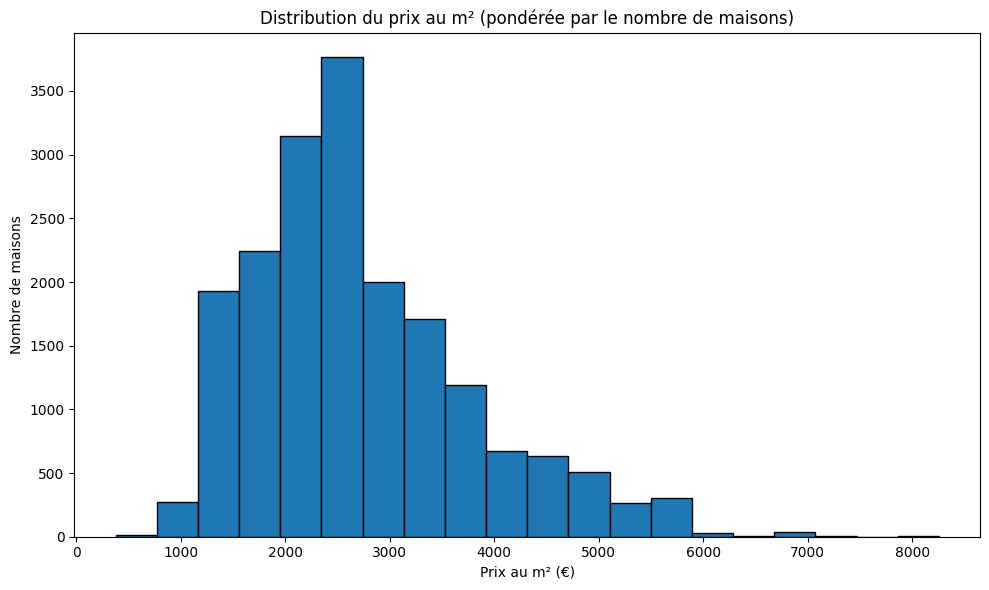

In [11]:
# paramétrage de l'histogramme
df_graph = pd.read_csv("../csv/STEP05/STEP05_all_bretagne.csv")
plt.figure(figsize=(10,6))
plt.hist(
    df_graph["Prix moyen au m2"],
    bins=20,
    weights=df_graph["Nombre de maisons à vendre"],
    edgecolor="black"
)

plt.xlabel("Prix au m² (€)")
plt.ylabel("Nombre de maisons")
plt.title("Distribution du prix au m² (pondérée par le nombre de maisons)")

plt.tight_layout()
plt.show()


# Ajout de la colonne "Département" à partir du code INSEE

In [12]:
# création et ajout de la colonne departement 
df_graph = pd.read_csv("../csv/STEP05/STEP05_all_bretagne.csv")
df_graph["departement"] = df_graph["Code INSEE"].astype(str).str.zfill(5).str[:2]
df_graph.head(10)


,Code INSEE,Nombre de maisons à vendre,Prix moyen au m2,Ville,departement
0,22001,8,1204,Allineuc 22460,22
1,22002,1,2800,Andel 22400,22
2,22003,3,2155,Aucaleuc 22100,22
3,22004,18,2348,Begard 22140,22
4,22005,9,1411,Belle-Isle-En-Terre 22810,22
5,22006,1,2846,Berhet 22140,22
6,22008,4,2251,Bobital 22100,22
7,22009,1,1289,Le Bodeo 22320,22
8,22011,9,2100,Boqueho 22170,22
9,22012,4,3006,La Bouillie 22240,22


# Création du Violin plot : Distribution du prix au m2 par département

C:\Users\rgb\AppData\Local\Temp\ipykernel_12932\4078832350.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


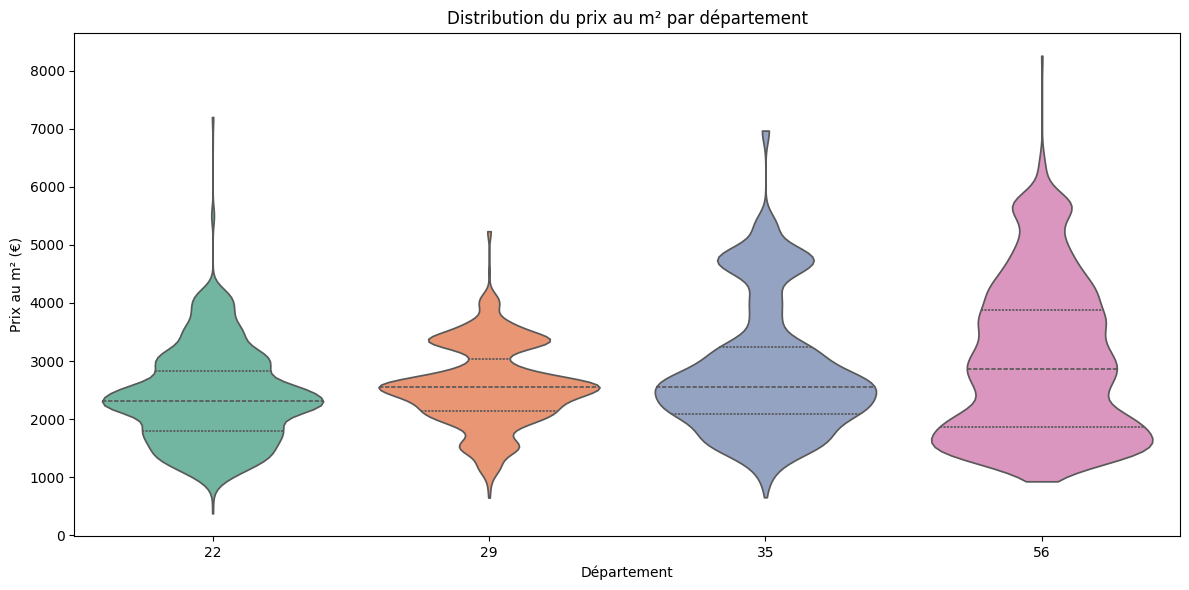

In [13]:
# Duplication des lignes pour pondérer les données dans le violin plot suivant. 1 ligne = 1 maison à vendre.
df_rep = df_graph.loc[df_graph.index.repeat(df_graph["Nombre de maisons à vendre"])]


plt.figure(figsize=(12,6))

sns.violinplot(
    x="departement",
    y="Prix moyen au m2",
    data=df_rep,
    inner="quartile",
    palette="Set2",
    cut=0
)

plt.xlabel("Département")
plt.ylabel("Prix au m² (€)")
plt.title("Distribution du prix au m² par département")

plt.tight_layout()
plt.show()


# 

# Création du Scatter Plot : Prix au m2 vs Nombre de maisons à vendre par commune

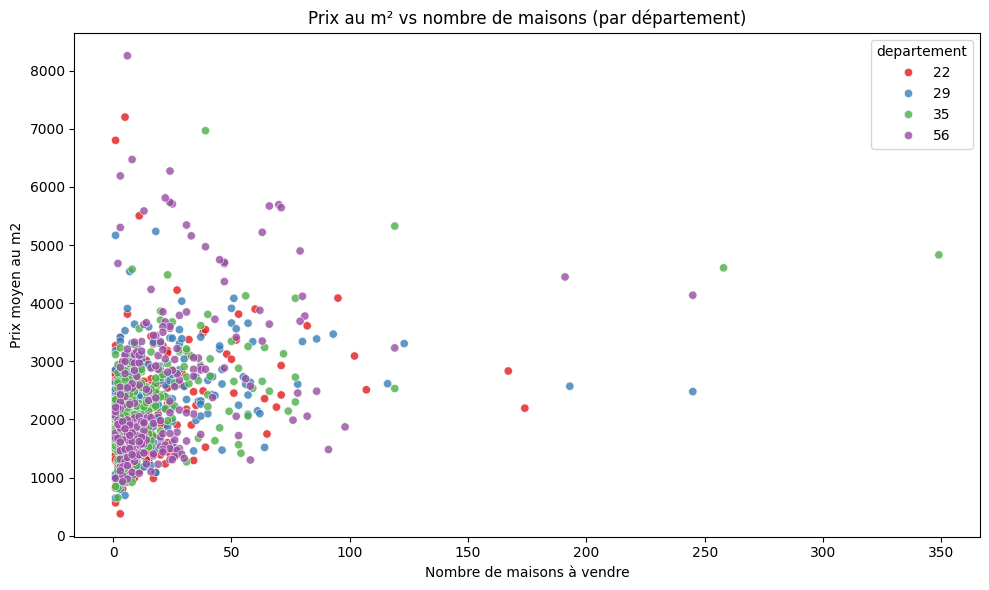

In [14]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df_graph,
    x="Nombre de maisons à vendre",
    y="Prix moyen au m2",
    hue="departement",
    palette="Set1",
    alpha=0.8
)


plt.title("Prix au m² vs nombre de maisons (par département)")
plt.tight_layout()
plt.show()
